# Car Price Prediction using Machine Learning

Predicting the resale price of used cars based on features like brand, mileage, fuel type, and transmission using regression models.

---

## 1. Import Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

## 2. Load Dataset

In [55]:
df = pd.read_csv('/content/car data.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [57]:
df.describe().round(2)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


## 3. Exploratory Data Analysis

In [58]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    print(f'\n{col}:')
    print(df[col].value_counts())

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2

Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


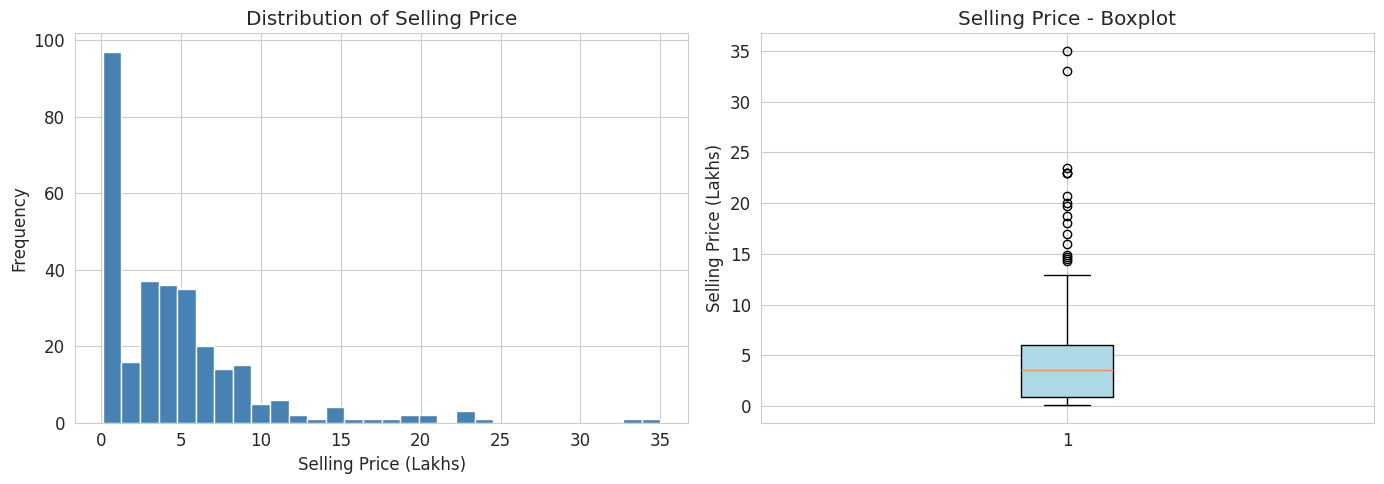

Skewness: 2.49


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Selling_Price'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Selling Price - Boxplot')
axes[1].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()
print(f'Skewness: {df["Selling_Price"].skew():.2f}')

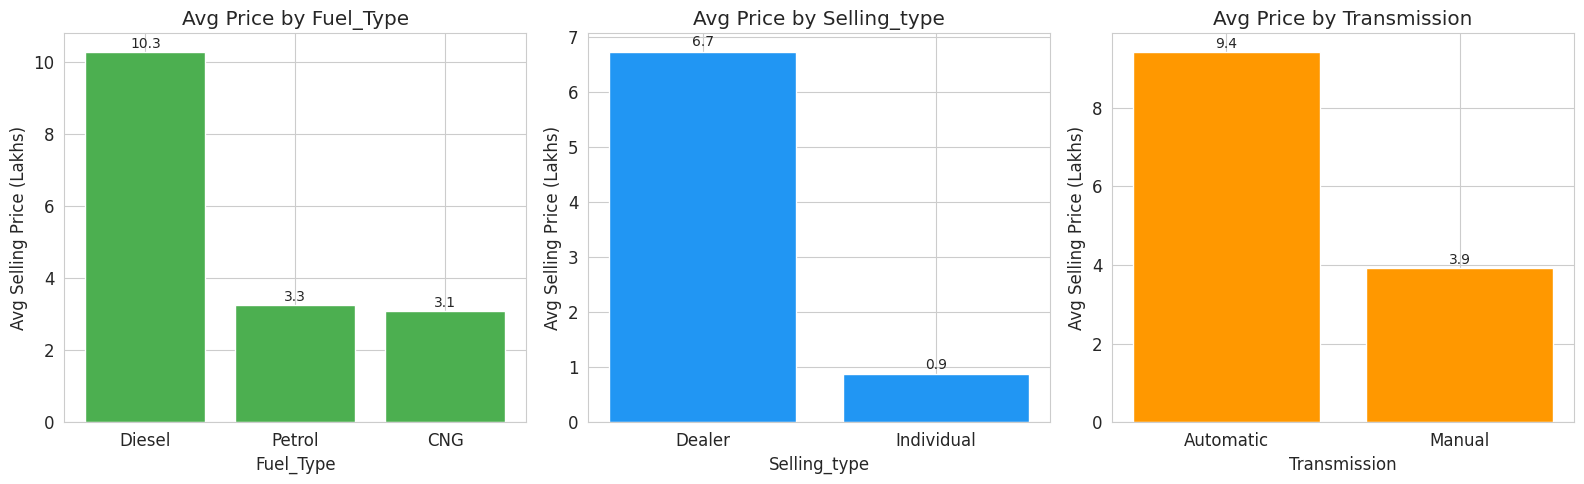

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
colors = ['#4CAF50', '#2196F3', '#FF9800']

for i, col in enumerate(cat_cols):
    avg = df.groupby(col)['Selling_Price'].mean().sort_values(ascending=False)
    axes[i].bar(avg.index, avg.values, color=colors[i], edgecolor='white')
    axes[i].set_title(f'Avg Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Selling Price (Lakhs)')
    for j, v in enumerate(avg.values):
        axes[i].text(j, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

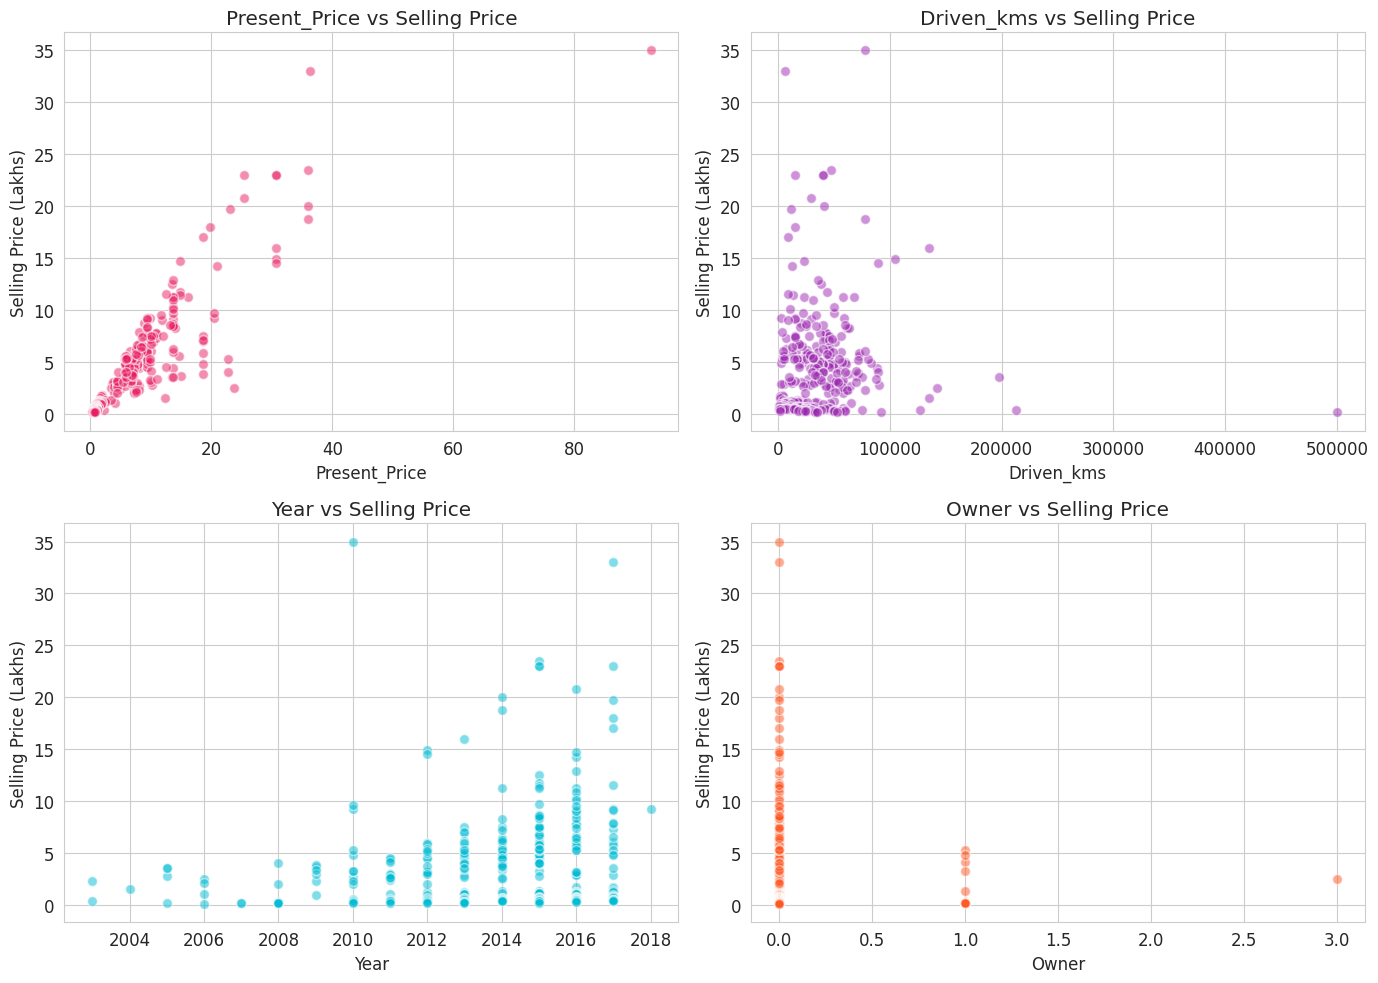

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

numeric_features = ['Present_Price', 'Driven_kms', 'Year', 'Owner']
scatter_colors = ['#E91E63', '#9C27B0', '#00BCD4', '#FF5722']

for i, col in enumerate(numeric_features):
    axes[i].scatter(df[col], df['Selling_Price'], alpha=0.5, color=scatter_colors[i], edgecolors='white', s=50)
    axes[i].set_title(f'{col} vs Selling Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

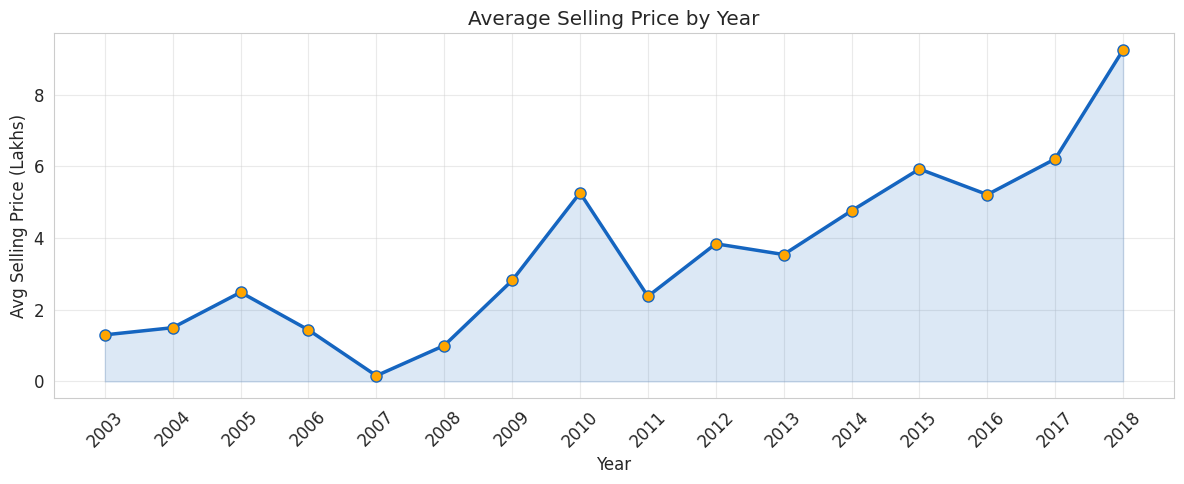

In [62]:
year_avg = df.groupby('Year')['Selling_Price'].mean()

plt.figure(figsize=(12, 5))
plt.plot(year_avg.index, year_avg.values, marker='o', linewidth=2.5,
         color='#1565C0', markersize=8, markerfacecolor='orange')
plt.fill_between(year_avg.index, year_avg.values, alpha=0.15, color='#1565C0')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Avg Selling Price (Lakhs)')
plt.xticks(year_avg.index, rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

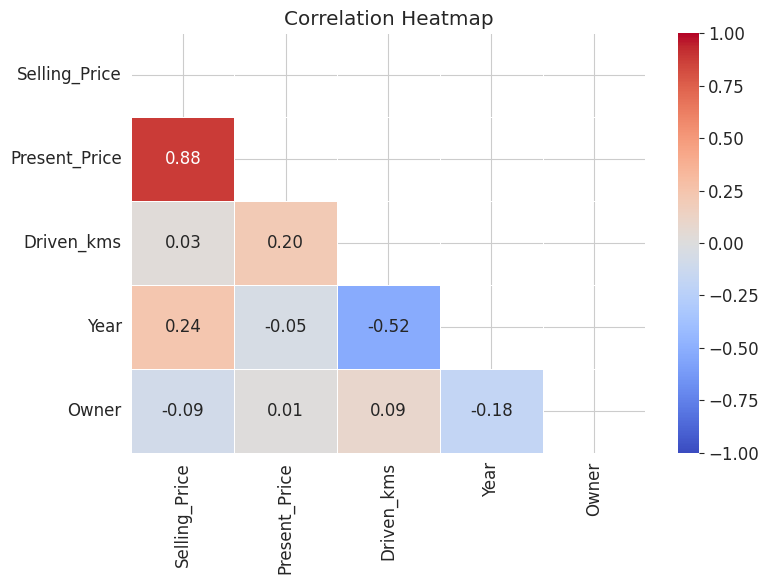

In [63]:
numeric_df = df[['Selling_Price', 'Present_Price', 'Driven_kms', 'Year', 'Owner']]
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 12})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

In [64]:
df_processed = df.copy()

# Car Age
current_year = 2024
df_processed['Car_Age'] = current_year - df_processed['Year']

# Depreciation ratio
df_processed['Depreciation_Ratio'] = (
    (df_processed['Present_Price'] - df_processed['Selling_Price']) / df_processed['Present_Price']
).round(4)

# Average KM driven per year
df_processed['KM_Per_Year'] = (
    df_processed['Driven_kms'] / df_processed['Car_Age'].replace(0, 1)
).round(0)

df_processed[['Car_Name', 'Year', 'Car_Age', 'Depreciation_Ratio', 'KM_Per_Year']].head()

,Car_Name,Year,Car_Age,Depreciation_Ratio,KM_Per_Year
0,ritz,2014,10,0.4007,2700.0
1,sx4,2013,11,0.5021,3909.0
2,ciaz,2017,7,0.2640,986.0
3,wagon r,2011,13,0.3133,400.0
4,swift,2014,10,0.3304,4245.0


In [65]:
le = LabelEncoder()
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

df_processed.drop(['Car_Name', 'Year'], axis=1, inplace=True)

print(f'Final shape: {df_processed.shape}')
df_processed.head()

Final shape: (301, 10)


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Depreciation_Ratio,KM_Per_Year
0,3.35,5.59,27000,2,0,1,0,10,0.4007,2700.0
1,4.75,9.54,43000,1,0,1,0,11,0.5021,3909.0
2,7.25,9.85,6900,2,0,1,0,7,0.2640,986.0
3,2.85,4.15,5200,2,0,1,0,13,0.3133,400.0
4,4.60,6.87,42450,1,0,1,0,10,0.3304,4245.0


In [66]:
X = df_processed.drop('Selling_Price', axis=1)
y = df_processed['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Features: {X.columns.tolist()}')

Train: 240 | Test: 61
Features: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Depreciation_Ratio', 'KM_Per_Year']


In [67]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Model Training

In [68]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.01),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

linear_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
results = []

for name, model in models.items():
    Xtr, Xte = (X_train_scaled, X_test_scaled) if name in linear_models else (X_train, X_test)

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2').mean()

    results.append({'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3),
                    'R²': round(r2, 4), 'CV R²': round(cv_r2, 4)})
    print(f'{name:<25} | R²={r2:.4f} | RMSE={rmse:.3f} | MAE={mae:.3f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)

Linear Regression         | R²=0.8814 | RMSE=1.653 | MAE=1.066
Ridge Regression          | R²=0.8804 | RMSE=1.660 | MAE=1.068
Lasso Regression          | R²=0.8799 | RMSE=1.663 | MAE=1.070
Decision Tree             | R²=0.9600 | RMSE=0.959 | MAE=0.555
Random Forest             | R²=0.9827 | RMSE=0.632 | MAE=0.381
Gradient Boosting         | R²=0.9879 | RMSE=0.528 | MAE=0.302


## 6. Model Evaluation

In [69]:
results_df

,Model,MAE,RMSE,R²,CV R²
0,Gradient Boosting,0.302,0.528,0.9879,0.9113
1,Random Forest,0.381,0.632,0.9827,0.8847
2,Decision Tree,0.555,0.959,0.9600,0.8371
3,Linear Regression,1.066,1.653,0.8814,0.8445
4,Ridge Regression,1.068,1.660,0.8804,0.8535
5,Lasso Regression,1.070,1.663,0.8799,0.8545


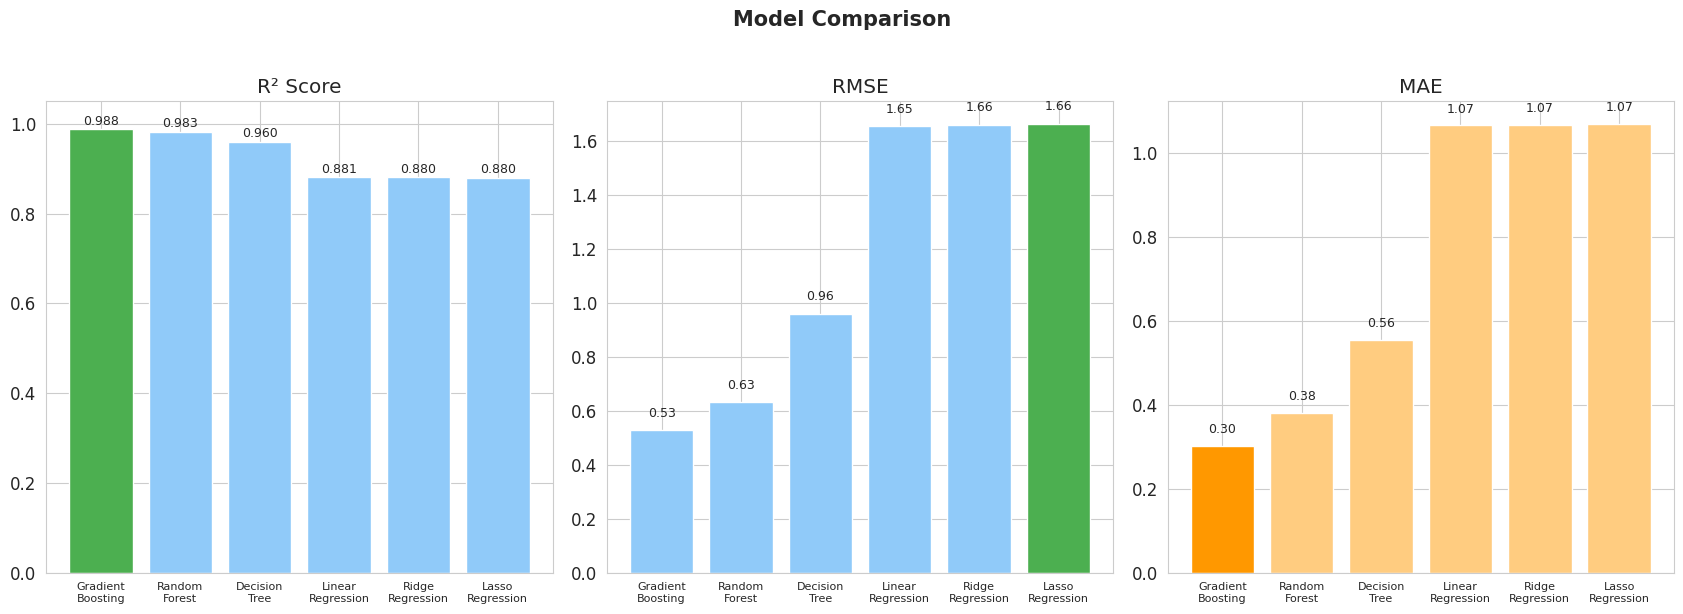

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
model_names = [m.replace(' ', '\n') for m in results_df['Model']]
bar_colors  = ['#4CAF50' if i == 0 else '#90CAF9' for i in range(len(results_df))]

bars0 = axes[0].bar(model_names, results_df['R²'], color=bar_colors, edgecolor='white')
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars0, results_df['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

bars1 = axes[1].bar(model_names, results_df['RMSE'], color=bar_colors[::-1], edgecolor='white')
axes[1].set_title('RMSE')
for bar, val in zip(bars1, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=9)

bars2 = axes[2].bar(model_names, results_df['MAE'],
                    color=['#FF9800' if i == 0 else '#FFCC80' for i in range(len(results_df))],
                    edgecolor='white')
axes[2].set_title('MAE')
for bar, val in zip(bars2, results_df['MAE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Best Model : Gradient Boosting
R²         : 0.9879
RMSE       : 0.5281
MAE        : 0.3016


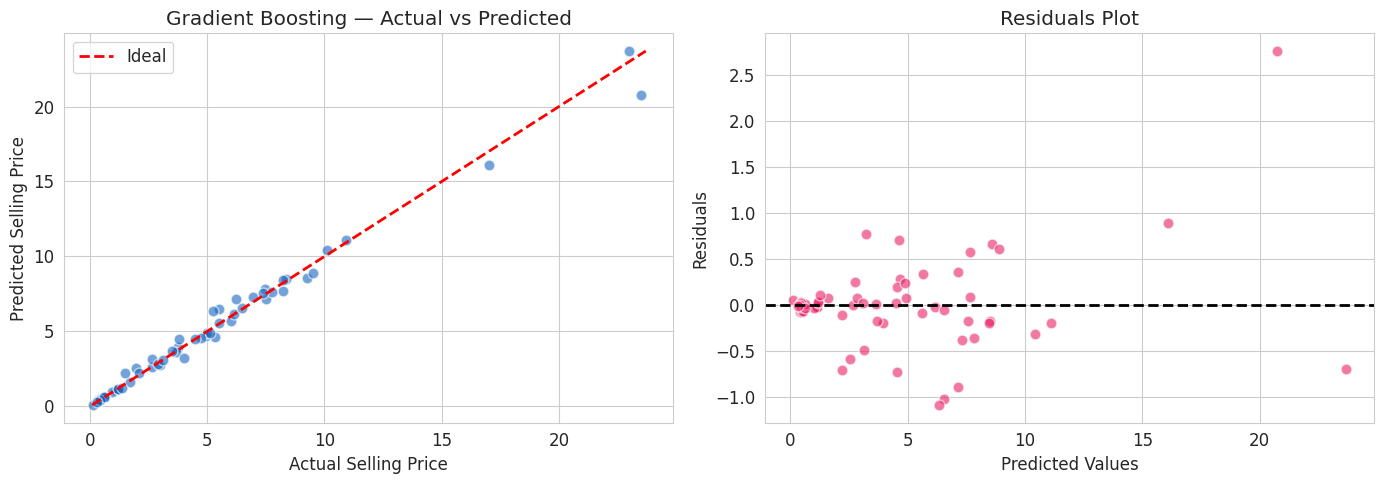

In [71]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled if best_model_name in linear_models else X_test)

print(f'Best Model : {best_model_name}')
print(f'R²         : {r2_score(y_test, y_pred_best):.4f}')
print(f'RMSE       : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'MAE        : {mean_absolute_error(y_test, y_pred_best):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#1565C0', edgecolors='white', s=60)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')
axes[0].set_title(f'{best_model_name} — Actual vs Predicted')
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].legend()

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='#E91E63', edgecolors='white', s=60)
axes[1].axhline(0, color='black', linewidth=2, linestyle='--')
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — Random Forest

In [72]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f'Best Params : {grid_search.best_params_}')
print(f'CV R²       : {grid_search.best_score_:.4f}')
print(f'Test R²     : {r2_score(y_test, y_pred_tuned):.4f}')
print(f'Test RMSE   : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}')
print(f'Test MAE    : {mean_absolute_error(y_test, y_pred_tuned):.4f}')

Best Params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
CV R²       : 0.8884
Test R²     : 0.9798
Test RMSE   : 0.6816
Test MAE    : 0.4052


## 8. Feature Importance

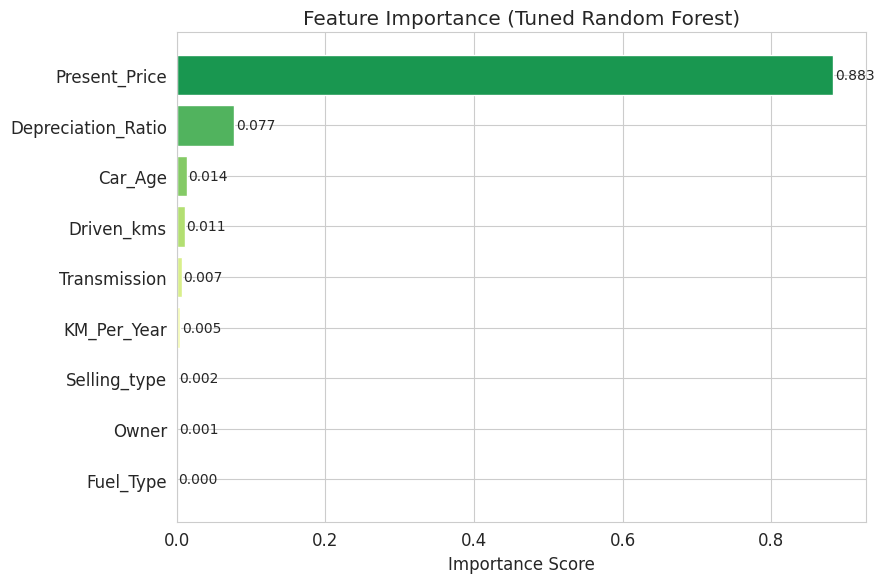

Present_Price         : 0.8834 (88.3%)
Depreciation_Ratio    : 0.0774 (7.7%)
Car_Age               : 0.0136 (1.4%)
Driven_kms            : 0.0107 (1.1%)
Transmission          : 0.0071 (0.7%)
KM_Per_Year           : 0.0050 (0.5%)
Selling_type          : 0.0018 (0.2%)
Owner                 : 0.0007 (0.1%)
Fuel_Type             : 0.0005 (0.0%)


In [73]:
importance = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance)))
bars = plt.barh(importance.index, importance.values, color=colors, edgecolor='white')
plt.title('Feature Importance (Tuned Random Forest)')
plt.xlabel('Importance Score')

for bar, val in zip(bars, importance.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

for feat, imp in importance.sort_values(ascending=False).items():
    print(f'{feat:<22}: {imp:.4f} ({imp*100:.1f}%)')

## 9. Predict Price for a New Car

In [74]:
# Encoding used:
#   Fuel_Type    -> Diesel=0, Petrol=1, CNG=2
#   Selling_type -> Dealer=0, Individual=1
#   Transmission -> Automatic=0, Manual=1

new_car = pd.DataFrame([{
    'Present_Price'     : 6.87,
    'Driven_kms'        : 30000,
    'Fuel_Type'         : 1,
    'Selling_type'      : 0,
    'Transmission'      : 1,
    'Owner'             : 0,
    'Car_Age'           : 2024 - 2016,
    'Depreciation_Ratio': (6.87 - 4.0) / 6.87,
    'KM_Per_Year'       : 30000 / (2024 - 2016)
}])

new_car = new_car[X_train.columns]
predicted_price = best_rf.predict(new_car)[0]

print(f'Predicted Selling Price: Rs. {predicted_price:.2f} Lakhs')

Predicted Selling Price: Rs. 3.95 Lakhs


## 10. Cross Validation

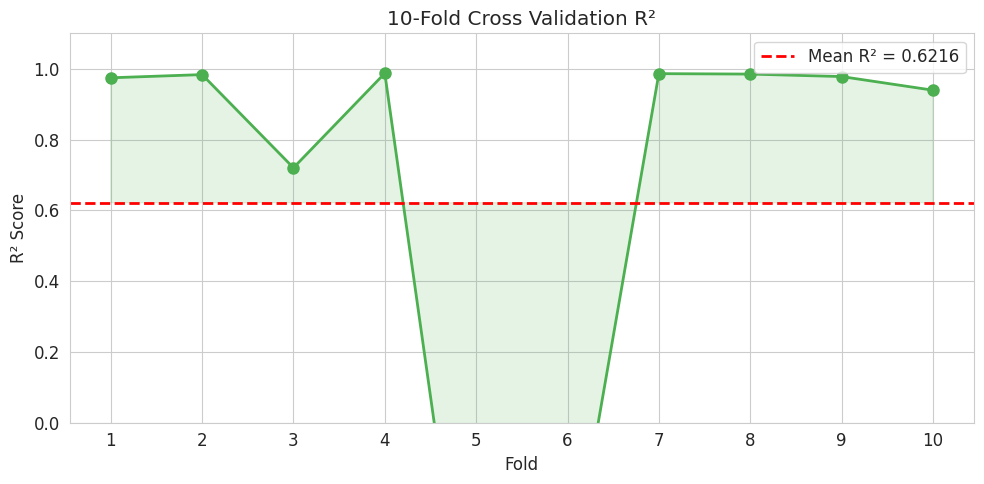

Scores : [ 0.9744  0.9834  0.7201  0.9873 -0.8381 -0.4997  0.9861  0.9849  0.9779
  0.9394]
Mean   : 0.6216
Std    : 0.6542


In [75]:
cv_scores = cross_val_score(best_rf, X, y, cv=10, scoring='r2')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), cv_scores, marker='o', linewidth=2, color='#4CAF50', markersize=8)
plt.axhline(cv_scores.mean(), color='red', linewidth=2, linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.fill_between(range(1, 11), cv_scores, cv_scores.mean(), alpha=0.15, color='#4CAF50')
plt.title('10-Fold Cross Validation R²')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.legend()
plt.xticks(range(1, 11))
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(f'Scores : {cv_scores.round(4)}')
print(f'Mean   : {cv_scores.mean():.4f}')
print(f'Std    : {cv_scores.std():.4f}')